# 라이브러리 설치

In [85]:
!python -m pip install numpy pandas matplotlib seaborn folium

# 라이브러리 임포트

In [86]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import folium

In [87]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터를 읽어들여 데이터 프레임 만들기

In [88]:
bike_temp = pd.read_csv('../data/bike_rent_1.csv', encoding='cp949', parse_dates=['대여일시'])  # datetime자료형으로 변환 - 대여일시
bike_temp.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930


In [89]:
bike_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 399999 entries, 0 to 399998
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   자전거번호     399999 non-null  str           
 1   대여일시      399999 non-null  datetime64[us]
 2   대여 대여소번호  399999 non-null  int64         
 3   대여 대여소명   399999 non-null  str           
 4   이용시간      399999 non-null  int64         
 5   이용거리      399999 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 18.3 MB


In [90]:
bike_dictionary = {}

for file_number in range(1, 7):
    file_name = f'../data/bike_rent_{file_number}.csv'
    bike_csv = pd.read_csv(file_name, encoding='cp949', parse_dates=['대여일시'])
    bike_dictionary[file_number] = bike_csv

In [91]:
bike_dictionary

{1:             자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  이용거리
 0       SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27  1330
 1       SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54  1180
 2       SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12  1930
 3       SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6  1340
 4       SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5  1230
 ...           ...                 ...       ...                ...   ...   ...
 399994  SPB-16680 2019-06-28 17:14:00       316         종각역 1번출구 앞    16  2360
 399995  SPB-07874 2019-06-28 16:59:00       345         서울보증보험본사 앞    32  1880
 399996  SPB-21622 2019-06-28 16:44:00       526           용답토속공원 앞    64  6100
 399997  SPB-20056 2019-06-28 17:46:00       453  종로오가 지하쇼핑센터 14번출구     7   880
 399998  SPB-18692 2019-06-28 17:34:00       345         서울보증보험본사 앞    35  1820
 
 [399999 rows x 6 columns],
 2:    

In [92]:
print(type(bike_dictionary), type(bike_dictionary[1]))

<class 'dict'> <class 'pandas.DataFrame'>


In [93]:
# DataFrame 합치기 (concat) 
# ignore_index 기존 인덱스를 무시하고 다시 순서를 0부터 생성한다
bikes = pd.concat(bike_dictionary, ignore_index=True)
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [94]:
bikes.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


# 데이터 프레임 관찰

In [95]:
bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2215632 entries, 0 to 2215631
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     str           
 1   대여일시      datetime64[us]
 2   대여 대여소번호  int64         
 3   대여 대여소명   str           
 4   이용시간      int64         
 5   이용거리      int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 101.4 MB


In [96]:
bikes.shape

(2215632, 6)

In [97]:
bikes.describe()

,대여일시,대여 대여소번호,이용시간,이용거리
count,2215632,2215632.00,2215632.00,2215632.00
mean,2019-06-16 08:40:01.500303,1226.15,27.17,3912.92
min,2019-06-01 00:00:00,3.00,1.00,0.00
25%,2019-06-08 22:04:00,505.00,8.00,1220.00
50%,2019-06-16 15:13:00,1159.00,17.00,2270.00
75%,2019-06-23 20:22:00,1846.00,37.00,4670.00
max,2019-06-30 23:59:00,9998.00,3133.00,232310.00
std,NaN,849.92,29.08,5145.47


In [98]:
bikes.index

RangeIndex(start=0, stop=2215632, step=1)

In [99]:
bikes.columns

Index(['자전거번호', '대여일시', '대여 대여소번호', '대여 대여소명', '이용시간', '이용거리'], dtype='str')

In [100]:
pd.options.display.float_format='{:.2f}'.format

In [101]:
bikes.isnull()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2215627,False,False,False,False,False,False
2215628,False,False,False,False,False,False
2215629,False,False,False,False,False,False
2215630,False,False,False,False,False,False


In [102]:
bikes.isnull().sum()

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
dtype: int64

# 날짜와 시간 계산을 위한 새로운 컬럼 추가

In [103]:
bikes['대여일시'].dt.day.head()

0     3
1     3
2     5
3     5
4    10
Name: 대여일시, dtype: int32

In [104]:
bikes['일자'] = bikes['대여일시'].dt.day
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10


In [105]:
bikes['대여일시'].dt.hour.head()

0    8
1    8
2    8
3    8
4    8
Name: 대여일시, dtype: int32

In [106]:
bikes['대여시간대'] = bikes['대여일시'].dt.hour
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8


In [107]:
bikes['대여일시'].dt.dayofweek.head()

0    0
1    0
2    2
3    2
4    0
Name: 대여일시, dtype: int32

In [108]:
weeks ={0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

bikes['대여일시'].dt.dayofweek.apply(lambda x: weeks[x]).head()

0    월
1    월
2    수
3    수
4    월
Name: 대여일시, dtype: str

In [122]:
# 대여일시에서 dayofweek을 추출해서 요일 컬럼으로 추가하기 
# 이때 요일이 숫자이므로 요일 이름으로 변환해서 추가 
bikes['요일'] = bikes['대여일시'].dt.dayofweek.apply(lambda x: weeks[x])
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일


In [123]:
bikes['주말구분'] = bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')

In [124]:
temp1 = bikes['주말구분'] = bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일


In [125]:
temp1[temp1 == '주말']

23         주말
32         주말
33         주말
34         주말
35         주말
           ..
2215590    주말
2215591    주말
2215614    주말
2215615    주말
2215619    주말
Name: 대여일시, Length: 737033, dtype: str

In [126]:
bikes.iloc[23]

자전거번호                 SPB-23160
대여일시        2019-06-16 07:27:00
대여 대여소번호                    704
대여 대여소명             남부법원검찰청 교차로
이용시간                         31
이용거리                       6700
일자                           16
대여시간대                         7
요일                            일
주말구분                         주말
Name: 23, dtype: object

In [127]:
bikes.loc[bikes['요일'] == '금']

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
13,SPB-03652,2019-06-21 08:34:00,529,장한평역 8번 출구 앞,6,1260,21,8,금,평일
14,SPB-20807,2019-06-21 08:45:00,646,장한평역 1번출구 (국민은행앞),20,1350,21,8,금,평일
20,SPB-22897,2019-06-28 08:44:00,646,장한평역 1번출구 (국민은행앞),19,1180,28,8,금,평일
24,SPB-24696,2019-06-21 08:23:00,911,은평평화공원(역촌역4번출구),32,5740,21,8,금,평일
238,SPB-08588,2019-06-07 08:54:00,102,망원역 1번출구 앞,10,1220,7,8,금,평일
...,...,...,...,...,...,...,...,...,...,...
2215587,SPB-12946,2019-06-14 03:55:00,2377,수서역 5번출구 뒤,6,1200,14,3,금,평일
2215588,SPB-11513,2019-06-14 09:54:00,9997,강남센터,8,30,14,9,금,평일
2215604,SPB-24266,2019-06-21 08:03:00,839,보광동 삼성리버빌아파트 앞,30,6650,21,8,금,평일
2215605,SPB-21482,2019-06-21 11:00:00,9997,강남센터,15,0,21,11,금,평일


# 장소적 특성에 따른 컬럼 추가

In [129]:
bike_shop = pd.read_csv('../data/bike_shop.csv', encoding='cp949')
bike_shop.head(3)

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14


In [130]:
bike_shop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      1537 non-null   str    
 1   대여소번호   1537 non-null   int64  
 2   대여소명    1537 non-null   str    
 3   위도      1537 non-null   float64
 4   경도      1537 non-null   float64
 5   거치대수    1537 non-null   int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 72.2 KB


In [131]:
bike_shop[['구분', '대여소번호', '대여소명', '위도', '경도']]

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91
...,...,...,...,...,...
1532,광진구,3537,아차산 휴먼시아 아파트 옆,37.55,127.09
1533,성동구,3538,서울숲 IT캐슬,37.55,127.04
1534,강동구,3539,서원마을,37.56,127.13
1535,광진구,3541,커먼그라운드,37.55,127.09


In [132]:
bike_shop.drop('거치대수', axis=1)

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91
...,...,...,...,...,...
1532,광진구,3537,아차산 휴먼시아 아파트 옆,37.55,127.09
1533,성동구,3538,서울숲 IT캐슬,37.55,127.04
1534,강동구,3539,서원마을,37.56,127.13
1535,광진구,3541,커먼그라운드,37.55,127.09


In [133]:
bike_gu = bike_shop.drop('거치대수', axis=1) 
bike_gu.head()

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91


In [134]:
bikes_merged = pd.merge(bikes, bike_gu, left_on='대여 대여소번호', right_on='대여소번호')
bikes_merged.head(3)


,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,대여소번호,대여소명,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,526,526. 용답토속공원 앞,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06


In [139]:
bike_dropped = bikes_merged.drop(['대여소번호', '대여소명'], axis=1)
bike_dropped.head(3)


,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


In [141]:
bikes_renamed = bike_dropped.rename(columns={'구분': '대여구', '위도': '대여점위도', '경도': '대여점경도'})
bikes_renamed.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,대여점위도,대여점경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


# 시간에 따른 시각화

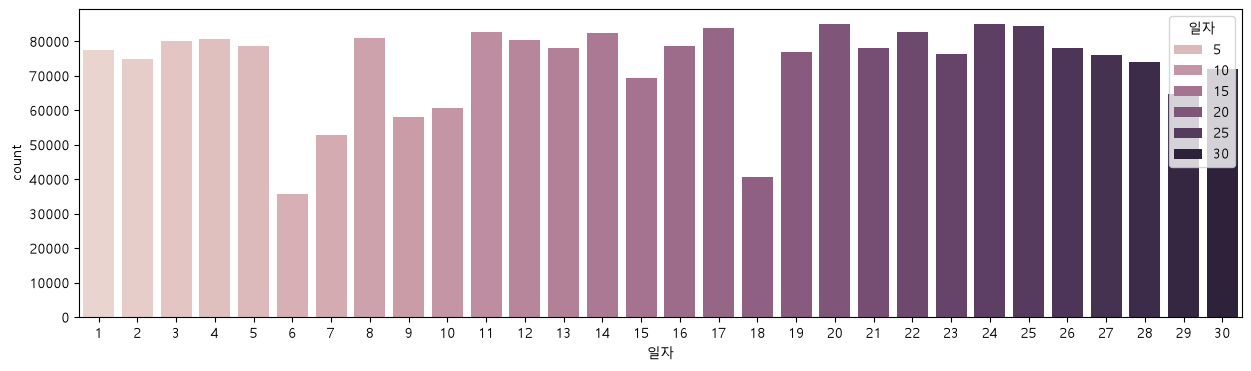

In [146]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='일자', hue='일자')
plt.show()

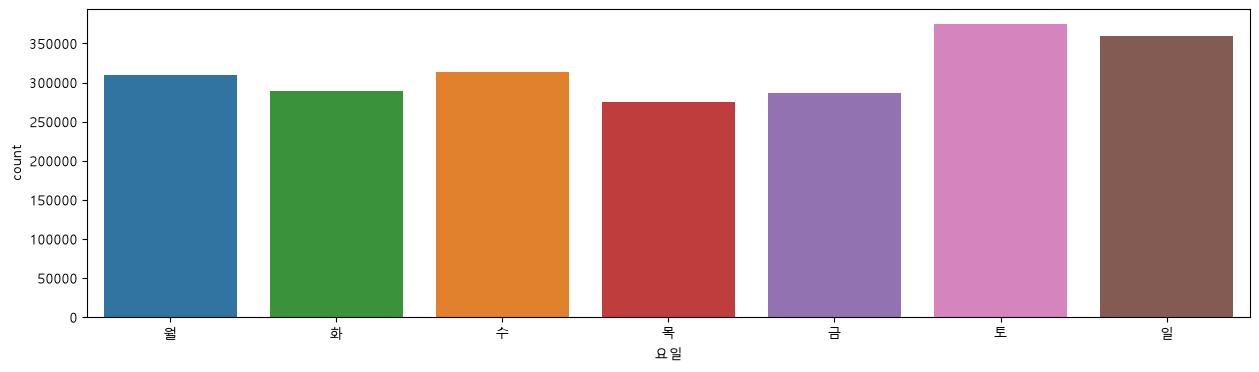

In [145]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='요일', hue='요일', order=['월', '화', '수', '목', '금', '토', '일'])
plt.show()

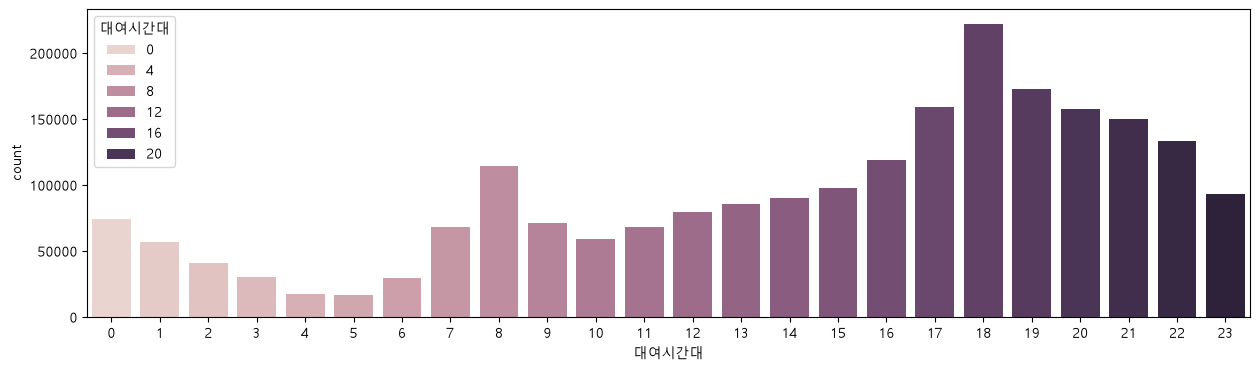

In [147]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='대여시간대', hue='대여시간대')
plt.show()

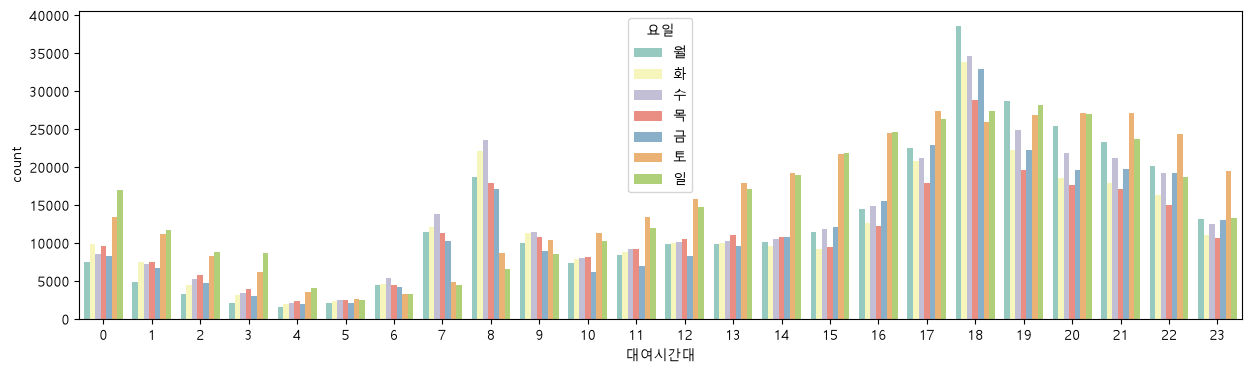

In [151]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='대여시간대', hue='요일', palette='Set3', hue_order=['월', '화', '수', '목', '금', '토', '일'])
plt.show()

# 피벗 테이블 

In [153]:
hourly_dayofweek_ride = bikes_renamed.pivot_table(index='대여시간대', columns='요일', values='자전거번호', aggfunc='count')
hourly_dayofweek_ride.head(3)

요일,금,목,수,월,일,토,화
대여시간대,,,,,,,
0,8353,9568,8624,7461,17025,13438,9907
1,6748,7508,7226,4846,11731,11232,7529
2,4762,5857,5328,3305,8804,8348,4497


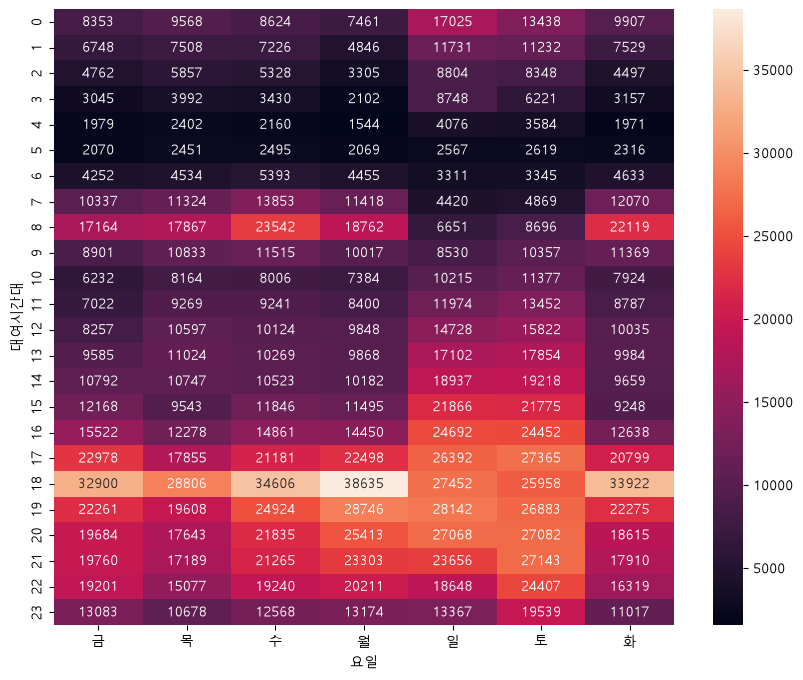

In [155]:
plt.figure(figsize=(10,8))
sns.heatmap(data=hourly_dayofweek_ride, annot=True, fmt='d')
pass

# 주말 구분에 따른 시각화

In [156]:
hourly_weekend_ride = bikes_renamed.pivot_table(index='대여시간대', columns='주말구분', values='자전거번호', aggfunc='count')
hourly_weekend_ride.head(3)

주말구분,주말,평일
대여시간대,,
0,30463,43913
1,22963,33857
2,17152,23749


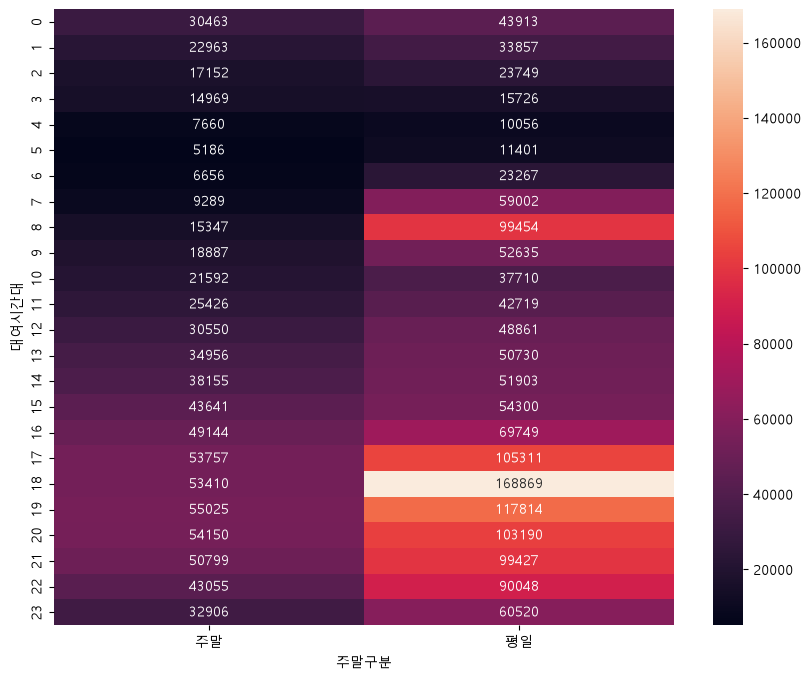

In [157]:
plt.figure(figsize=(10,8))
sns.heatmap(data=hourly_weekend_ride, annot=True, fmt='d')
pass